# Memory Importance Classification for LLM Agents

Can supervised ML predict which conversational memories will matter in the future, better than plain similarity-based retrieval?

This notebook demonstrates the end-to-end pipeline: loading the Multi-Session Chat (MSC) dataset, extracting features, performing exploratory data analysis and dimensionality reduction (PCA), training five ML classifiers using StratifiedGroupKFold cross-validation, comparing them with a similarity baseline, and running an Ollama LLM demo with four memory strategies.

## Step 0: Set Up Environment and Imports

In [1]:
import os
import sys
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Ensure project root is in path
sys.path.insert(0, os.path.abspath('.'))

from src import config
from src.data_loader import load_msc, generate_synthetic
from src.features import build_dataset, FEATURE_COLUMNS
from src.train import cross_validate, get_models, fit_final_model, pca_analysis
from src.evaluate import plot_model_comparison, plot_curves, plot_feature_importance, plot_pca_scree
from src.llm_demo import run_demo

print("Environment initialized. Using device settings from config:")
print(f"Ollama model: {config.OLLAMA_MODEL}")
print(f"Embedding model: {config.EMBEDDING_MODEL}")

Environment initialized. Using device settings from config:
Ollama model: llama3.1:8b-instruct-q4_K_M
Embedding model: all-MiniLM-L6-v2


## Step 1: Load Conversations

We load the Multi-Session Chat (MSC) conversations. Memories are extracted from earlier sessions, and the final session serves as the source of future references (labels) and the current query.

In [2]:
try:
    # Load 100 conversations from the real MSC dataset
    conversations = load_msc(max_conversations=100)
    print(f"Loaded {len(conversations)} conversations from real MSC dataset.")
except FileNotFoundError:
    print("Real MSC dataset not found. Falling back to synthetic conversations for testing.")
    conversations = generate_synthetic(n_conversations=50)
    print(f"Generated {len(conversations)} synthetic conversations.")

Loaded 100 conversations from real MSC dataset.


## Step 2: Feature Engineering and Label Generation

We process the raw conversations to extract 10 key features per memory and generate heuristic binary importance labels. The labels identify whether a memory is referenced in the final session via semantic similarity, lexical overlap, or shared entities.

In [3]:
df = build_dataset(conversations)
df.head()

/Users/raghav/my files/projects/project/memory-importance-classifier/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 6083.07it/s]

[embeddings] Using SentenceTransformer: all-MiniLM-L6-v2


[features] processed 50 conversations


[features] processed 100 conversations
[features] 1617 memories from 100 conversations | positive rate = 0.176


,conversation_id,query_text,text,recency,session_gap,access_frequency,semantic_similarity,role_user,sentence_length,is_question,entity_count,first_person,position_in_session,label
0,0,When do you think you will travel to New Orlea...,I have been all over the world. I'm military.,37,3,0,0.169680,0,9,0,1,1,0.076923,0
1,0,When do you think you will travel to New Orlea...,That is good you have alot of travel experience,36,3,1,0.355059,1,9,0,0,0,0.153846,0
2,0,When do you think you will travel to New Orlea...,Sure do. And a lot of experience blowing thing...,35,3,0,0.191736,0,15,0,3,0,0.230769,1
3,0,When do you think you will travel to New Orlea...,I've been working non stop crazy hours and nee...,34,3,0,0.135139,1,11,0,0,1,0.307692,0
4,0,When do you think you will travel to New Orlea...,The best breaks are spent with cute cuddly kit...,33,3,0,0.087269,0,9,0,0,0,0.384615,0


## Step 3: Exploratory Data Analysis & Dimensionality Analysis

Let's look at the correlation of the features with the target label and run a Principal Component Analysis (PCA) to examine the explained variance.

In [4]:
# Correlation of engineered features with the target importance label
correlation = df[FEATURE_COLUMNS + ['label']].corr()['label'].sort_values(ascending=False)
print("Correlation of features with importance label:")
print(correlation)

Correlation of features with importance label:
label                  1.000000
entity_count           0.357681
semantic_similarity    0.248755
sentence_length        0.185931
first_person           0.092057
access_frequency      -0.002341
position_in_session   -0.034198
role_user             -0.057867
recency               -0.107243
session_gap           -0.137757
is_question                 NaN
Name: label, dtype: float64


In [5]:
# Run PCA
X = StandardScaler().fit_transform(df[FEATURE_COLUMNS].values)
pca = PCA().fit(X)
evr = pca.explained_variance_ratio_

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(np.arange(1, len(evr) + 1), np.cumsum(evr), "o-")
ax.set(title="PCA Cumulative Explained Variance",
       xlabel="Number of Components", ylabel="Cumulative Variance")
ax.axhline(0.95, ls="--", c="gray")
plt.show()

/var/folders/7k/8skcvkhn4pscp06q44f6qkzr0000gn/T/ipykernel_3769/1601582564.py:11: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


## Step 4: Model Cross-Validation and Comparison

We train 5 classification models using 5-fold StratifiedGroupKFold cross-validation (grouped by conversation to prevent data leakage) and compare their performance against a TopK-Similarity baseline.

In [6]:
results, oof = cross_validate(df)

[train] LogisticRegression F1=0.525  ROC-AUC=0.812  PR-AUC=0.478
[train] kNN                F1=0.458  ROC-AUC=0.759  PR-AUC=0.392


[train] DecisionTree       F1=0.479  ROC-AUC=0.758  PR-AUC=0.388


[train] RandomForest       F1=0.469  ROC-AUC=0.808  PR-AUC=0.468


[train] AdaBoost           F1=0.504  ROC-AUC=0.818  PR-AUC=0.541
[train] TopK-Similarity    F1=0.329  ROC-AUC=0.640  PR-AUC=0.386
[train] LogisticRegression_EqualBudget F1=0.489  ROC-AUC=0.811  PR-AUC=0.464
[train] kNN_EqualBudget    F1=0.428  ROC-AUC=0.760  PR-AUC=0.383
[train] DecisionTree_EqualBudget F1=0.418  ROC-AUC=0.756  PR-AUC=0.382
[train] RandomForest_EqualBudget F1=0.469  ROC-AUC=0.808  PR-AUC=0.453
[train] AdaBoost_EqualBudget F1=0.474  ROC-AUC=0.817  PR-AUC=0.532


## Step 5: Visualizing Evaluation Metrics

[plots] saved -> /Users/raghav/my files/projects/project/memory-importance-classifier/results/model_comparison.png


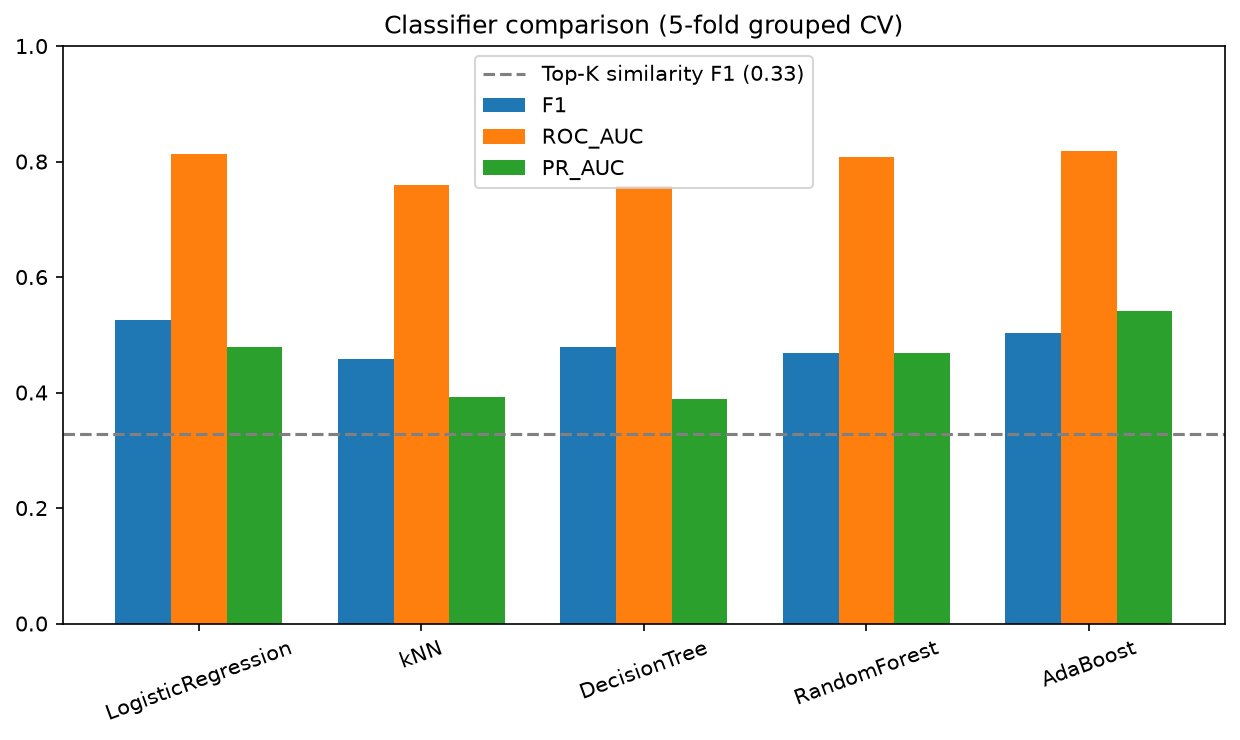

In [7]:
# Plot model comparison
plot_model_comparison(results)

# Show comparison plot inline
from IPython.display import Image, display
display(Image(filename=os.path.join(config.RESULTS_DIR, 'model_comparison.png')))

[plots] saved -> /Users/raghav/my files/projects/project/memory-importance-classifier/results/roc_pr_curves.png


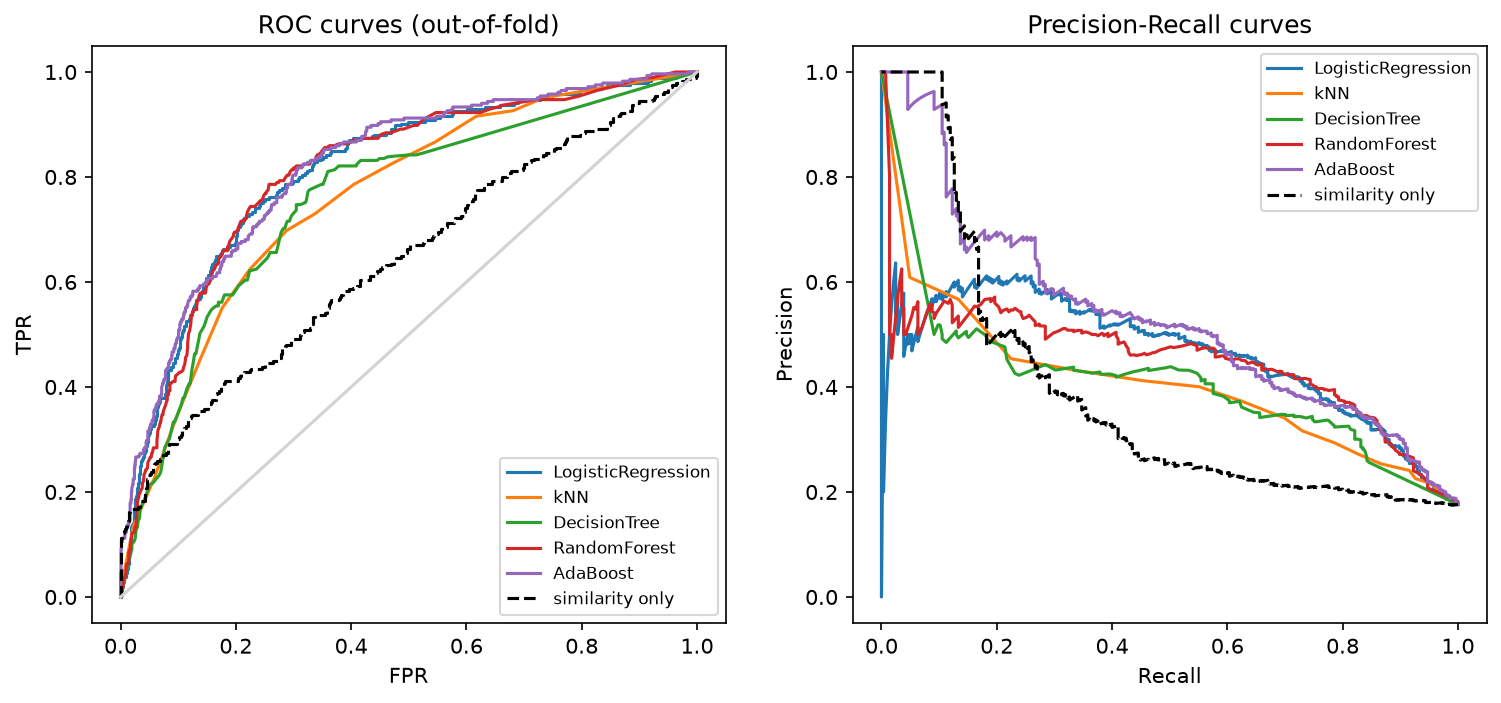

In [8]:
# Plot out-of-fold ROC and PR curves
plot_curves(df, oof)
display(Image(filename=os.path.join(config.RESULTS_DIR, 'roc_pr_curves.png')))

[plots] saved -> /Users/raghav/my files/projects/project/memory-importance-classifier/results/feature_importance.png


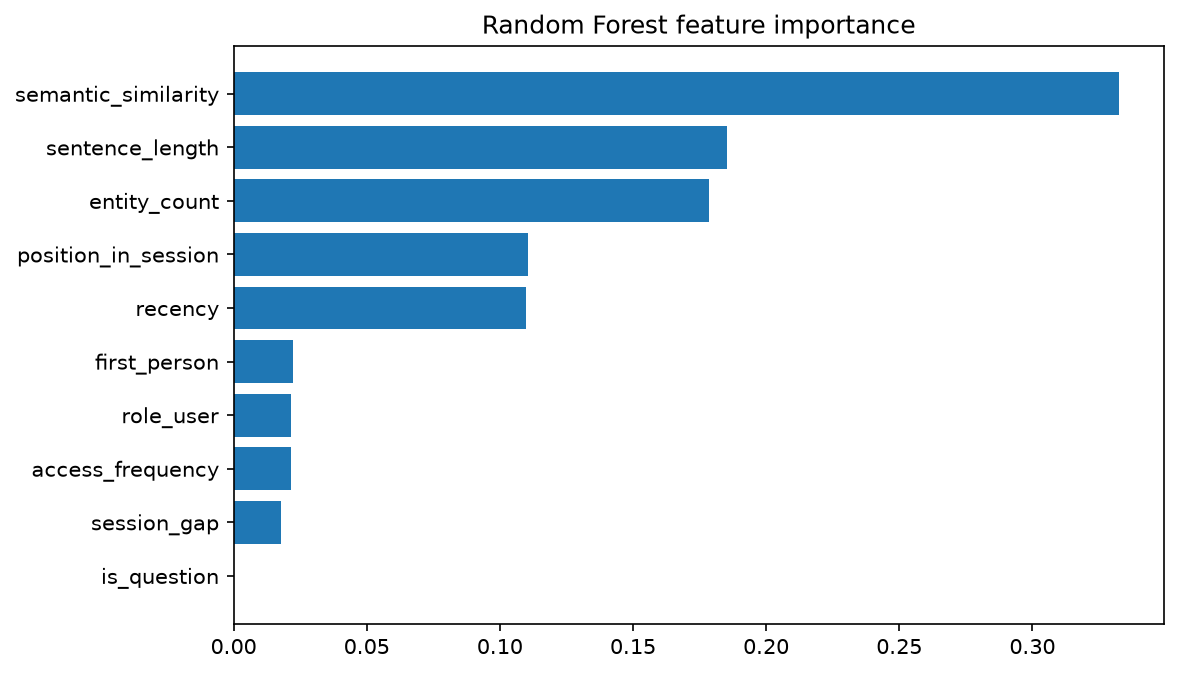

In [9]:
# Plot Random Forest Feature Importance
plot_feature_importance(df)
display(Image(filename=os.path.join(config.RESULTS_DIR, 'feature_importance.png')))

## Step 6: Fit Final Model and Run LLM Demo

We save the best classifier, and then run the LLM demo using Ollama (Llama 3.1) to observe how memory filtering affects conversational generation quality.

In [10]:
# Determine the best classifier name by F1-score
best_clf = max((n for n in results if not n.startswith("Baseline")), key=lambda n: results[n]["f1"])
print(f"Fitting final model for best classifier: {best_clf}")
fit_final_model(df, best_clf)

# Run the LLM demo using the saved model
run_demo(df, dry_run=True)

Fitting final model for best classifier: LogisticRegression
[train] saved final model (LogisticRegression) -> /Users/raghav/my files/projects/project/memory-importance-classifier/results/best_model.pkl
[demo] conv 0 | no_memory    | 0 memories
[demo] conv 0 | store_all    | 26 memories
[demo] conv 0 | top_k        | 5 memories
[demo] conv 0 | ml_selected  | 7 memories
[demo] conv 1 | no_memory    | 0 memories
[demo] conv 1 | store_all    | 18 memories
[demo] conv 1 | top_k        | 5 memories
[demo] conv 1 | ml_selected  | 6 memories
[demo] conv 2 | no_memory    | 0 memories
[demo] conv 2 | store_all    | 11 memories
[demo] conv 2 | top_k        | 5 memories
[demo] conv 2 | ml_selected  | 4 memories
[demo] conv 3 | no_memory    | 0 memories
[demo] conv 3 | store_all    | 19 memories
[demo] conv 3 | top_k        | 5 memories
[demo] conv 3 | ml_selected  | 7 memories
[demo] conv 4 | no_memory    | 0 memories
[demo] conv 4 | store_all    | 14 memories
[demo] conv 4 | top_k        | 5 memo

In [11]:
# Display some demo results
demo_file = os.path.join(config.RESULTS_DIR, "llm_demo_outputs.json")
if os.path.exists(demo_file):
    with open(demo_file) as f:
        demo_data = json.load(f)
    
    # Print comparison for the first conversation
    first_conv = demo_data[0]
    print(f"Query: {first_conv['query']}\n")
    for strategy, info in first_conv['strategies'].items():
        print(f"Strategy: {strategy} (Memories: {info['n_memories']})")
        print(f"Response: {info['response']}\n")

Query: When do you think you will travel to New Orleans next?

Strategy: no_memory (Memories: 0)
Response: (dry run - Ollama not called)

Strategy: store_all (Memories: 26)
Response: (dry run - Ollama not called)

Strategy: top_k (Memories: 5)
Response: (dry run - Ollama not called)

Strategy: ml_selected (Memories: 7)
Response: (dry run - Ollama not called)

